## Data loading and preprocessing
- load data images into pandas DataFrame
- while loading, resize to 224x224 and normalize pixel values to [0, 1]
- the source data is already split into training, testing, and validation sets, each set can be loaded into separate DataFrames

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [6]:
HEIGHT = 224
WIDTH = 224

#data augmentation
train_aug = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, rotation_range=7, zoom_range=.03, brightness_range=[0.9,1.1], width_shift_range=.05, height_shift_range=.05)
test_val_aug = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

#load data
#flow from directory automatically labels data based on folder names
train = train_aug.flow_from_directory('./chest_xray/train', target_size=(HEIGHT, WIDTH), batch_size=32, class_mode='binary')
test = test_val_aug.flow_from_directory('./chest_xray/test', target_size=(HEIGHT, WIDTH), batch_size=32, class_mode='binary')
val = test_val_aug.flow_from_directory('./chest_xray/val', target_size=(HEIGHT, WIDTH), batch_size=32, class_mode='binary')

        

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


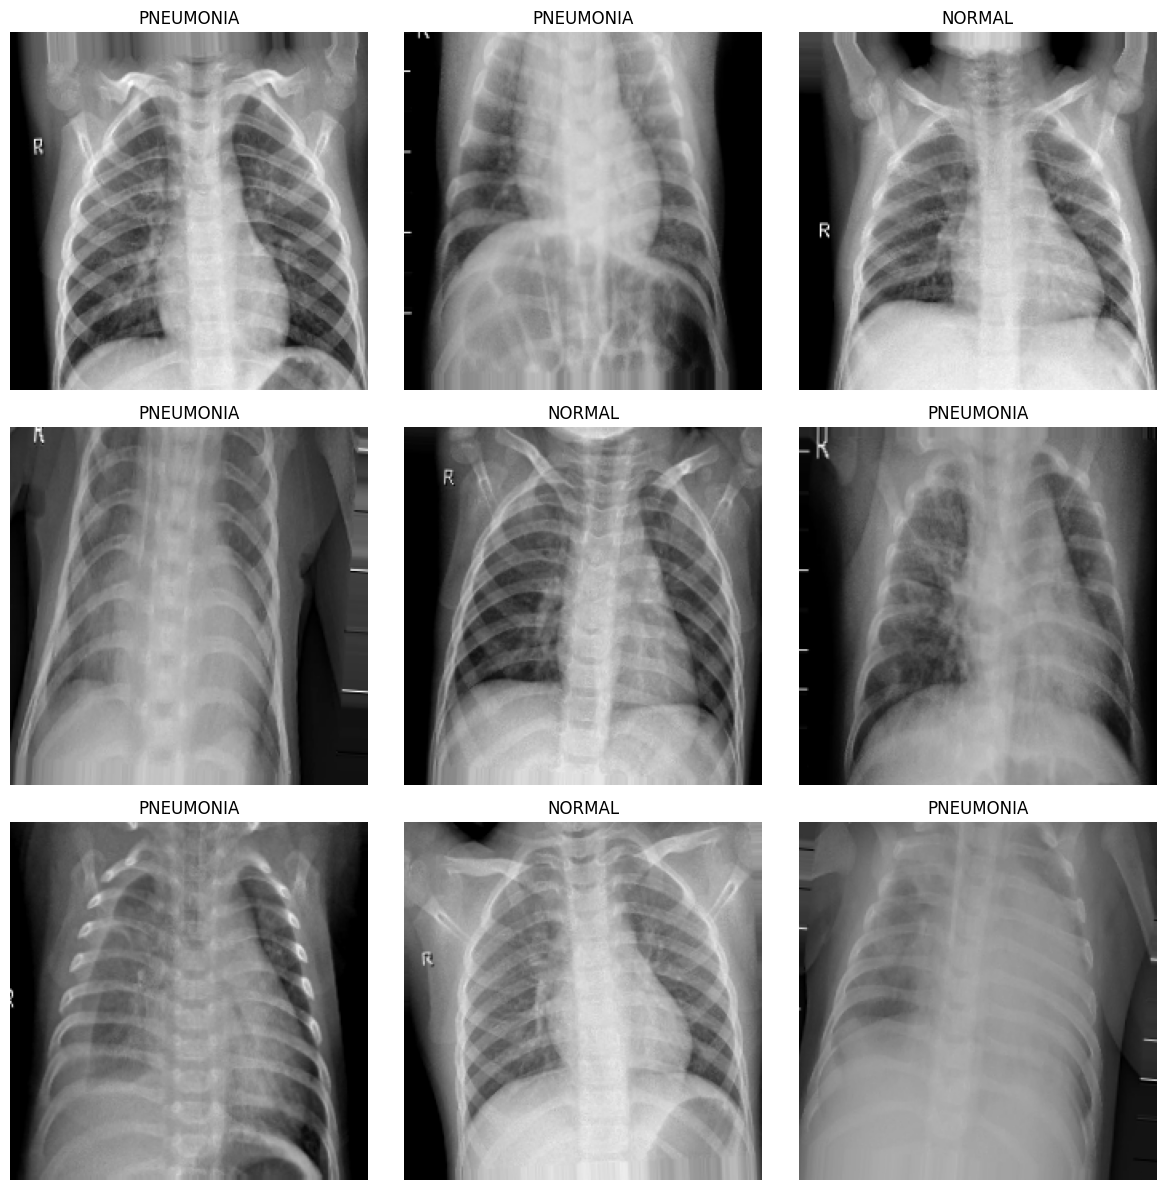

In [7]:
# Get a batch of augmented images
sample_batch = next(train)
images = sample_batch[0]  # Images
labels = sample_batch[1]  # Labels

# Plot first 9 augmented images
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Squeeze to remove channel dimension for grayscale
    plt.imshow(images[i].squeeze(), cmap='gray')
    label = 'PNEUMONIA' if labels[i] == 1 else 'NORMAL'
    plt.title(f'{label}')
    plt.axis('off')
plt.tight_layout()
plt.savefig('./chest_xray/augmented_samples.png')
plt.show()